In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = ['Microsoft JhengHei']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
import sys
print(sys.executable)

c:\Users\chent\Desktop\我的資料夾\學校\大學\三下\統計方法與資料採礦\DataMiningG1FinalProject\.venv\Scripts\python.exe


In [6]:
import pandas as pd
import os


if not os.path.exists(r"C:\Users\chent\.cache\kagglehub\datasets\shree0910\buy-now-and-pay-later-fintech-ml-dataset\versions\2\Buy_Now_Pay_Later_BNPL_CreditRisk_Dataset.csv"):
    import kagglehub
    from getpass import getpass

    # 1. 使用 Kaggle Access Token 進行身份驗證
    print("🔐 Kaggle 身份驗證")
    print("-" * 40)

    # 方法：使用 Access Token 設定環境變數
    username = input("請輸入您的 Kaggle 用戶名: ").strip()
    access_token = getpass("請輸入您的 Kaggle Access Token (輸入不會顯示): ")

    # 2. 設定環境變數
    os.environ["KAGGLE_USERNAME"] = username
    os.environ["KAGGLE_KEY"] = access_token
    
    # 3. 下載資料集
    try:
        print("\n📥 正在下載資料集...")
        path = kagglehub.dataset_download("shree0910/buy-now-and-pay-later-fintech-ml-dataset")
        print(f"✅ 資料集實際存放在：{path}")
        print("-" * 40)
        
        # 4. 在下載的資料夾中尋找 CSV 檔案
        csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
        
        if csv_files:
            # 組合出完整的 CSV 檔案路徑
            file_path = os.path.join(path, csv_files[0])
            print(f"準備讀取檔案：{file_path}\n" + "-"*40)
            
            # 5. 使用 Pandas 讀取資料
            df = pd.read_csv(file_path)
            print(f"✅ 資料集已成功載入")
            print(f"資料形狀: {df.shape}")
            
            # 6. 顯示前五筆資料
            print("\n資料預覽:")
            display(df.head())
            
        else:
            print("⚠️ 在這個資料夾中沒有找到 CSV 檔案")
    except Exception as e:
        print(f"❌ 下載資料集時出錯: {e}")
        print("請確認用戶名和 Access Token 正確")
        raise
else:
    df = pd.read_csv(r"C:\Users\chent\.cache\kagglehub\datasets\shree0910\buy-now-and-pay-later-fintech-ml-dataset\versions\2\Buy_Now_Pay_Later_BNPL_CreditRisk_Dataset.csv")

## 第一階段：探索性資料分析 (EDA)
EDA 的目的是先摸熟資料，了解欄位型態、分佈與缺失情況，為後續預處理做準備。

In [6]:
# 1. 顯示資料集基本形狀
print("資料筆數與欄位數:", df.shape)

# 2. 欄位型態與 non-null 數量
print("\n欄位型態與非空值數量:")
df.info()

# 3. 缺失值檢查
print("\n缺失值統計:")
display(df.isna().sum())

# 4. 重複資料檢查
print("\n重複資料筆數:", df.duplicated().sum())

# 5. 基本統計摘要（數值與類別欄位）
print("\n數值欄位摘要:")
display(df.describe())

print("\n所有欄位摘要:")
display(df.describe(include='all').T)


資料筆數與欄位數: (10345, 17)

欄位型態與非空值數量:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10345 entries, 0 to 10344
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               10345 non-null  int64  
 1   age                   10345 non-null  int64  
 2   employment_type       10345 non-null  object 
 3   monthly_income        10345 non-null  float64
 4   credit_score          10345 non-null  int64  
 5   purchase_amount       10345 non-null  float64
 6   product_category      10345 non-null  object 
 7   bnpl_installments     10345 non-null  int64  
 8   repayment_delay_days  10345 non-null  int64  
 9   missed_payments       10345 non-null  int64  
 10  default_flag          10345 non-null  int64  
 11  app_usage_frequency   10345 non-null  float64
 12  location              10345 non-null  object 
 13  transaction_date      10345 non-null  object 
 14  debt_to_income_ratio  10345 non-nul

user_id                 0
age                     0
employment_type         0
monthly_income          0
credit_score            0
purchase_amount         0
product_category        0
bnpl_installments       0
repayment_delay_days    0
missed_payments         0
default_flag            0
app_usage_frequency     0
location                0
transaction_date        0
debt_to_income_ratio    0
risk_score              0
customer_segment        0
dtype: int64


重複資料筆數: 0

數值欄位摘要:


,user_id,age,monthly_income,credit_score,purchase_amount,bnpl_installments,repayment_delay_days,missed_payments,default_flag,app_usage_frequency,debt_to_income_ratio,risk_score
count,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000
mean,5173.000000,38.559884,35053.381898,448.176124,3979.402721,7.477525,8.742774,1.015950,0.390527,5.524101,0.181071,198.534094
std,2986.488601,12.131789,27084.517277,136.518332,1500.828483,3.362867,6.781849,0.996726,0.487892,2.590364,0.124887,67.541384
min,1.000000,18.000000,5000.000000,300.000000,100.000000,3.000000,0.000000,0.000000,0.000000,1.000000,0.000811,0.000000
25%,2587.000000,28.000000,12207.020000,332.000000,2990.720000,3.000000,2.000000,0.000000,0.000000,3.300000,0.080187,153.600000
50%,5173.000000,39.000000,23800.520000,403.000000,5000.000000,9.000000,9.000000,1.000000,0.000000,5.550000,0.138263,202.800000
75%,7759.000000,49.000000,55276.930000,547.000000,5000.000000,9.000000,14.000000,2.000000,1.000000,7.750000,0.268300,250.800000
max,10345.000000,59.000000,145767.120000,850.000000,5000.000000,12.000000,33.000000,7.000000,1.000000,10.000000,0.723460,398.000000



所有欄位摘要:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_id,10345.0,NaN,NaN,NaN,5173.0,2986.488601,1.0,2587.0,5173.0,7759.0,10345.0
age,10345.0,NaN,NaN,NaN,38.559884,12.131789,18.0,28.0,39.0,49.0,59.0
employment_type,10345,4,Salaried,2632,NaN,NaN,NaN,NaN,NaN,NaN,NaN
monthly_income,10345.0,NaN,NaN,NaN,35053.381898,27084.517277,5000.0,12207.02,23800.52,55276.93,145767.12
credit_score,10345.0,NaN,NaN,NaN,448.176124,136.518332,300.0,332.0,403.0,547.0,850.0
purchase_amount,10345.0,NaN,NaN,NaN,3979.402721,1500.828483,100.0,2990.72,5000.0,5000.0,5000.0
product_category,10345,5,Fashion,2166,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bnpl_installments,10345.0,NaN,NaN,NaN,7.477525,3.362867,3.0,3.0,9.0,9.0,12.0
repayment_delay_days,10345.0,NaN,NaN,NaN,8.742774,6.781849,0.0,2.0,9.0,14.0,33.0
missed_payments,10345.0,NaN,NaN,NaN,1.01595,0.996726,0.0,0.0,1.0,2.0,7.0


## 統計學資料型態分類
資料型態可分為：
- **Categorical (類別型)**: 名目型 (nominal) - 無順序，如 employment_type, product_category, location, customer_segment
- **Ordinal (順序型)**: 有順序但間距不明確，如 credit_score (若視為等級)
- **Interval (區間型)**: 有等間距但無絕對零點，如 temperature (此資料集中無明顯範例)
- **Ratio (比率型)**: 有絕對零點，可比較倍數，如 age, monthly_income, purchase_amount 等數值欄位

以下根據欄位內容進行分類：

In [7]:
# 根據統計學分類欄位
data_types = {
    'Categorical': ['employment_type', 'product_category', 'location', 'customer_segment'],  # user_id 不需要
    'Ordinal': ['credit_score'],  # 視為信用等級
    'Interval': ['transaction_date'],  # 時間型欄位歸類為 Interval
    'Ratio': ['age', 'monthly_income', 'purchase_amount', 'bnpl_installments', 
                      'repayment_delay_days', 'missed_payments', 'default_flag', 'app_usage_frequency', 
                      'debt_to_income_ratio', 'risk_score']  
}

# 特殊處理：transaction_date 為日期時間，需轉換
print("資料型態分類：")
for category, columns in data_types.items():
    print(f"\n{category}:")
    for col in columns:
        if col in df.columns:
            dtype = df[col].dtype
            print(f"  - {col} ({dtype})")

# transaction_date 特殊處理
print(f"\n日期時間型: transaction_date ({df['transaction_date'].dtype}) - 建議轉換為 datetime")

資料型態分類：

Categorical:
  - employment_type (object)
  - product_category (object)
  - location (object)
  - customer_segment (object)

Ordinal:
  - credit_score (int64)

Interval:
  - transaction_date (object)

Ratio:
  - age (int64)
  - monthly_income (float64)
  - purchase_amount (float64)
  - bnpl_installments (int64)
  - repayment_delay_days (int64)
  - missed_payments (int64)
  - default_flag (int64)
  - app_usage_frequency (float64)
  - debt_to_income_ratio (float64)
  - risk_score (float64)

日期時間型: transaction_date (object) - 建議轉換為 datetime


## 根據資料型態的統計摘要
不同資料型態適合的統計量不同：
- **Categorical**: 計數、唯一值、最常見值
- **Ordinal**: 計數、平均、中位數、眾數、最小最大
- **Ratio**: 完整統計摘要（平均、標準差等）
- **日期時間型**: 時間範圍、格式檢查

=== Categorical 欄位統計 ===

employment_type:
  類別數量: 4
  最常見值: Salaried (出現 2632 次)
  所有值: {'Salaried': 2632, 'Unemployed': 2632, 'Self-Employed': 2550, 'Student': 2531}


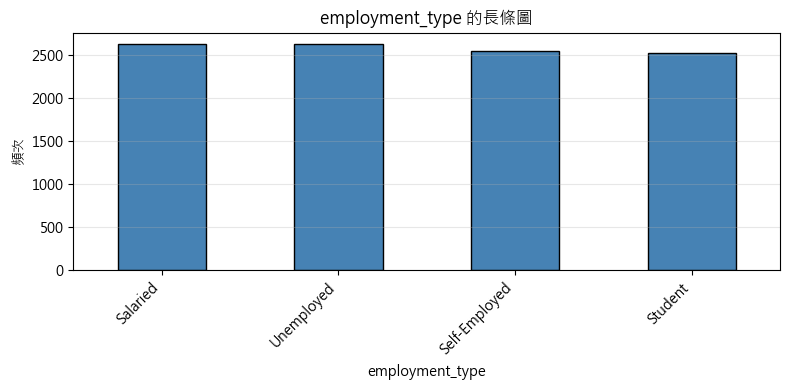


product_category:
  類別數量: 5
  最常見值: Fashion (出現 2166 次)
  所有值: {'Fashion': 2166, 'Electronics': 2085, 'Beauty': 2072, 'Home': 2052, 'Sports': 1970}


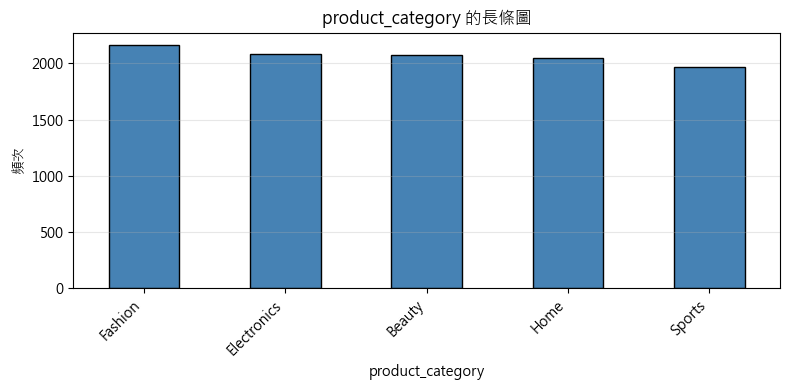


location:
  類別數量: 6
  最常見值: Germany (出現 1760 次)
  所有值: {'Germany': 1760, 'Canada': 1740, 'USA': 1736, 'India': 1723, 'Australia': 1722, 'UK': 1664}


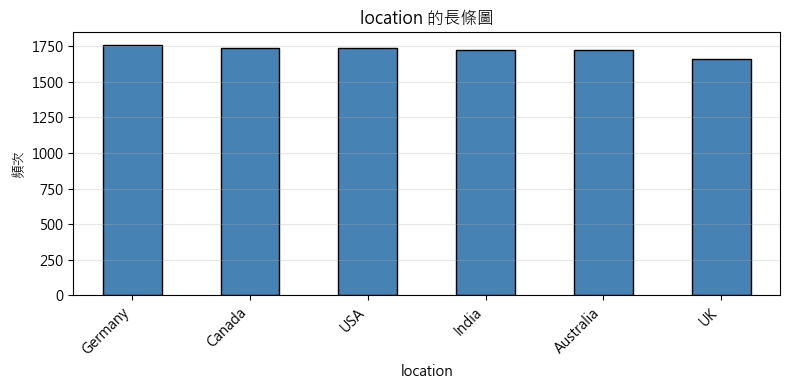


customer_segment:
  類別數量: 3
  最常見值: High Risk (出現 7569 次)
  所有值: {'High Risk': 7569, 'Medium Risk': 2200, 'Low Risk': 576}


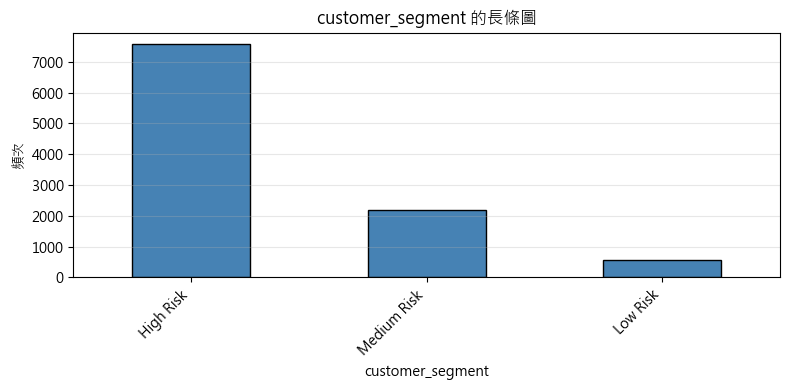

In [8]:
# Categorical統計
print("=== Categorical 欄位統計 ===")
for col in data_types['Categorical']:
    if col in df.columns:
        print(f"\n{col}:")
        print(f"  類別數量: {df[col].nunique()}")
        print(f"  最常見值: {df[col].mode().iloc[0]} (出現 {df[col].value_counts().iloc[0]} 次)")
        print(f"  所有值: {df[col].value_counts().to_dict()}")
        
        # 畫長條圖
        plt.figure(figsize=(8, 4))
        df[col].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
        plt.title(f"{col} 的長條圖")
        plt.xlabel(col)
        plt.ylabel('頻次')
        plt.grid(axis='y', alpha=0.3)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

=== Ordinal 欄位統計 ===
Ordinal 欄位清單: ['credit_score']
資料集欄位包含 Ordinal 欄位: ['credit_score']

credit_score:
  計數: 10345
  平均: 448.18
  中位數: 403.00
  眾數: 300
  最小值: 300
  最大值: 850
  標準差: 136.52


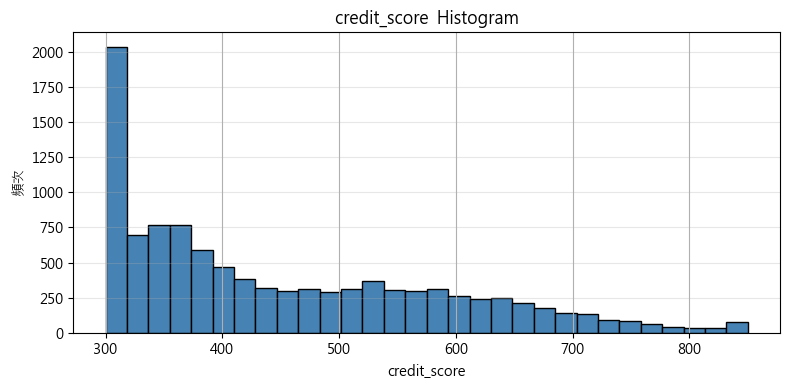

In [9]:
# Ordinal 統計
print("=== Ordinal 欄位統計 ===")
print(f"Ordinal 欄位清單: {data_types['Ordinal']}")
print(f"資料集欄位包含 Ordinal 欄位: {[col for col in data_types['Ordinal'] if col in df.columns]}")
for col in data_types['Ordinal']:
    if col in df.columns:
        print(f"\n{col}:")
        print(f"  計數: {df[col].count()}")
        print(f"  平均: {df[col].mean():.2f}")
        print(f"  中位數: {df[col].median():.2f}")
        print(f"  眾數: {df[col].mode().iloc[0]}")
        print(f"  最小值: {df[col].min()}")
        print(f"  最大值: {df[col].max()}")
        print(f"  標準差: {df[col].std():.2f}")
        
        plt.figure(figsize=(8, 4))
        df[col].hist(bins=30, color='steelblue', edgecolor='black')
        plt.title(f"{col}  Histogram")
        plt.xlabel(col)
        plt.ylabel('頻次')
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()
        
    else:
        print(f"\n! 注意: Ordinal 欄位 '{col}' 不在資料集中，未顯示統計結果。")

=== Ratio 欄位統計 ===

age:


count    10345.000000
mean        38.559884
std         12.131789
min         18.000000
25%         28.000000
50%         39.000000
75%         49.000000
max         59.000000
Name: age, dtype: float64

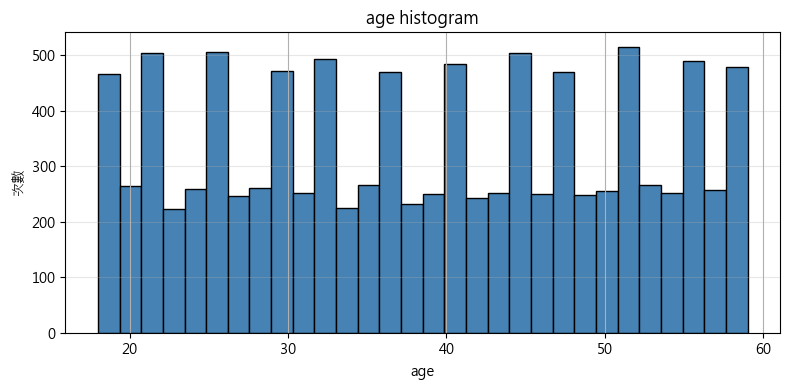


monthly_income:


count     10345.000000
mean      35053.381898
std       27084.517277
min        5000.000000
25%       12207.020000
50%       23800.520000
75%       55276.930000
max      145767.120000
Name: monthly_income, dtype: float64

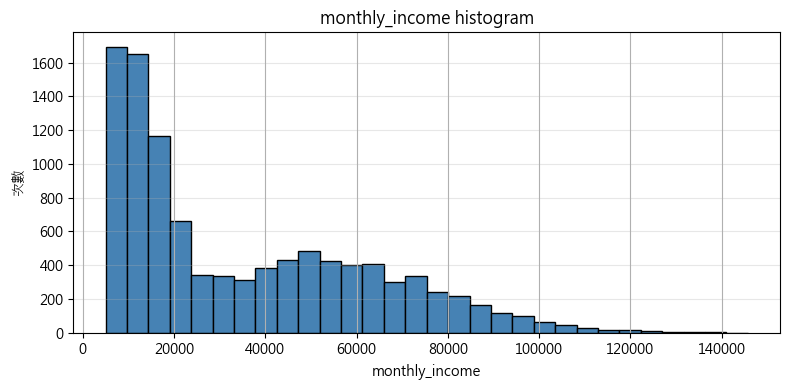


purchase_amount:


count    10345.000000
mean      3979.402721
std       1500.828483
min        100.000000
25%       2990.720000
50%       5000.000000
75%       5000.000000
max       5000.000000
Name: purchase_amount, dtype: float64

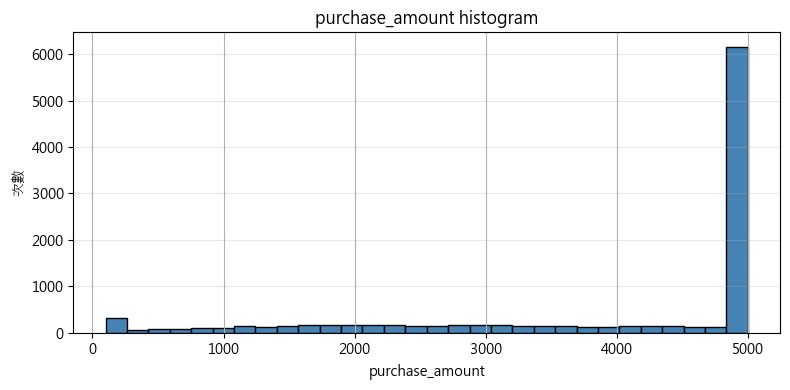


bnpl_installments:


count    10345.000000
mean         7.477525
std          3.362867
min          3.000000
25%          3.000000
50%          9.000000
75%          9.000000
max         12.000000
Name: bnpl_installments, dtype: float64

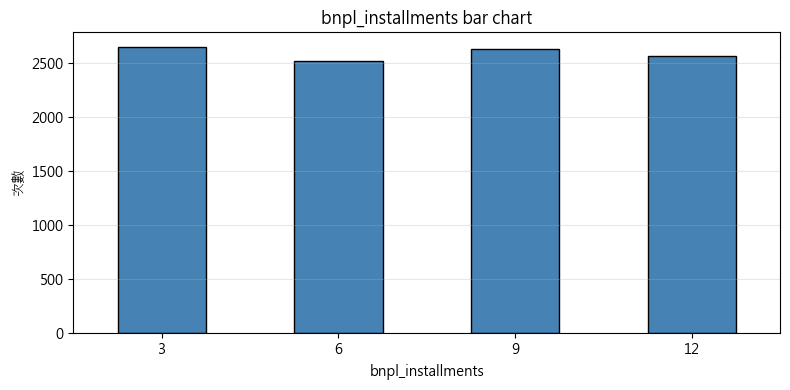


repayment_delay_days:


count    10345.000000
mean         8.742774
std          6.781849
min          0.000000
25%          2.000000
50%          9.000000
75%         14.000000
max         33.000000
Name: repayment_delay_days, dtype: float64

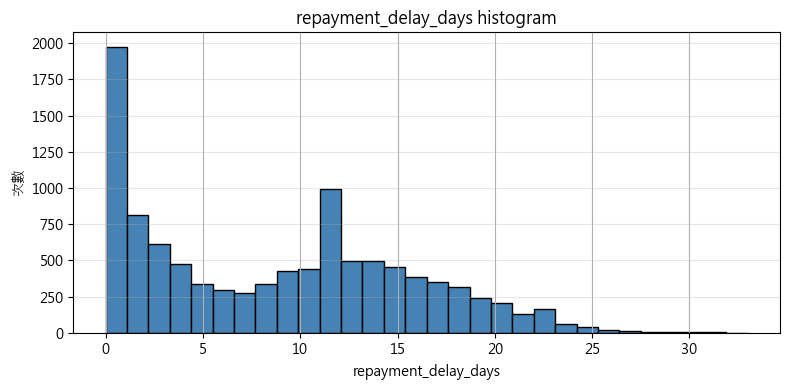


missed_payments:


count    10345.000000
mean         1.015950
std          0.996726
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max          7.000000
Name: missed_payments, dtype: float64

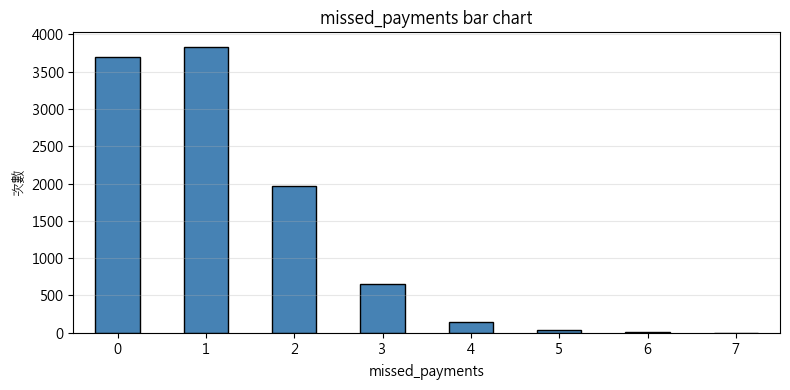


default_flag:


count    10345.000000
mean         0.390527
std          0.487892
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: default_flag, dtype: float64

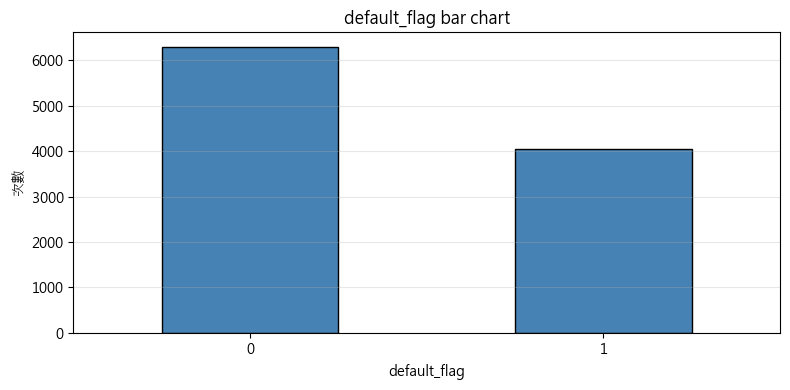


app_usage_frequency:


count    10345.000000
mean         5.524101
std          2.590364
min          1.000000
25%          3.300000
50%          5.550000
75%          7.750000
max         10.000000
Name: app_usage_frequency, dtype: float64

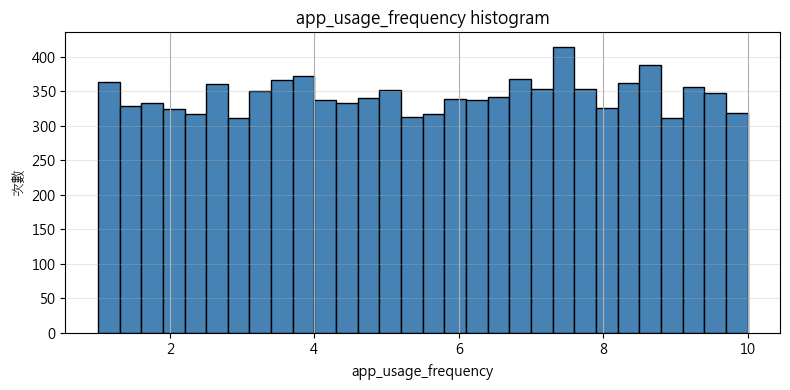


debt_to_income_ratio:


count    10345.000000
mean         0.181071
std          0.124887
min          0.000811
25%          0.080187
50%          0.138263
75%          0.268300
max          0.723460
Name: debt_to_income_ratio, dtype: float64

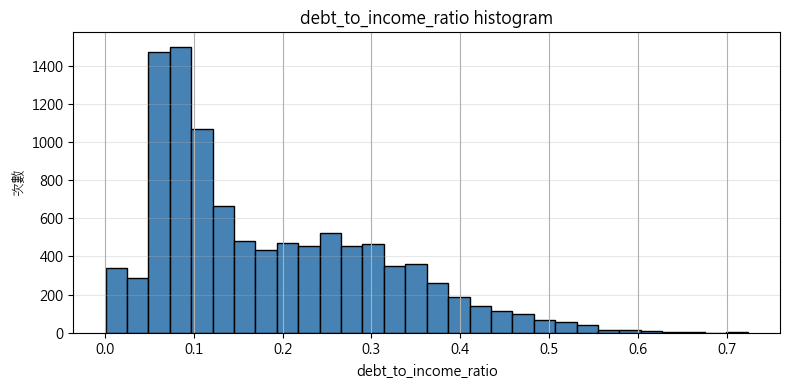


risk_score:


count    10345.000000
mean       198.534094
std         67.541384
min          0.000000
25%        153.600000
50%        202.800000
75%        250.800000
max        398.000000
Name: risk_score, dtype: float64

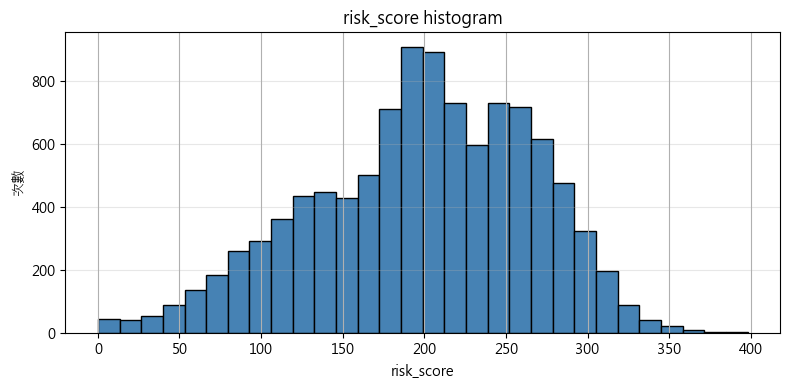

In [10]:
#Ratio統計
print("=== Ratio 欄位統計 ===")
for col in data_types['Ratio']:
    if col in df.columns:
        print(f"\n{col}:")
        display(df[col].describe().T)
        
        # 特殊處理：特定欄位使用長條圖
        if col in ['default_flag', 'missed_payments', 'bnpl_installments']:
            plt.figure(figsize=(8, 4))
            df[col].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
            plt.title(f"{col} bar chart")
            plt.xlabel(col)
            plt.ylabel('次數')
            plt.grid(axis='y', alpha=0.3)
            plt.xticks(rotation=0)
            plt.tight_layout()
            plt.show()
        else:
            # 其他欄位使用直方圖
            plt.figure(figsize=(8, 4))
            df[col].hist(bins=30, color='steelblue', edgecolor='black')
            plt.title(f"{col} histogram")
            plt.xlabel(col)
            plt.ylabel('次數')
            plt.grid(axis='y', alpha=0.3)
            plt.tight_layout()
            plt.show()

=== Interval 欄位統計與時間特徵提取 ===

transaction_date:
  計數: 10345
  開始時間: 2023-01-01 00:00:00
  結束時間: 2024-12-31 00:00:00
  時間跨度: 730 天
  缺失值: 0

  提取的特徵:
    - transaction_date_year
    - transaction_date_month
    - transaction_date_day
    - transaction_date_dayofweek (0=Monday, 6=Sunday)
    - transaction_date_is_weekend (1=Weekend, 0=Weekday)


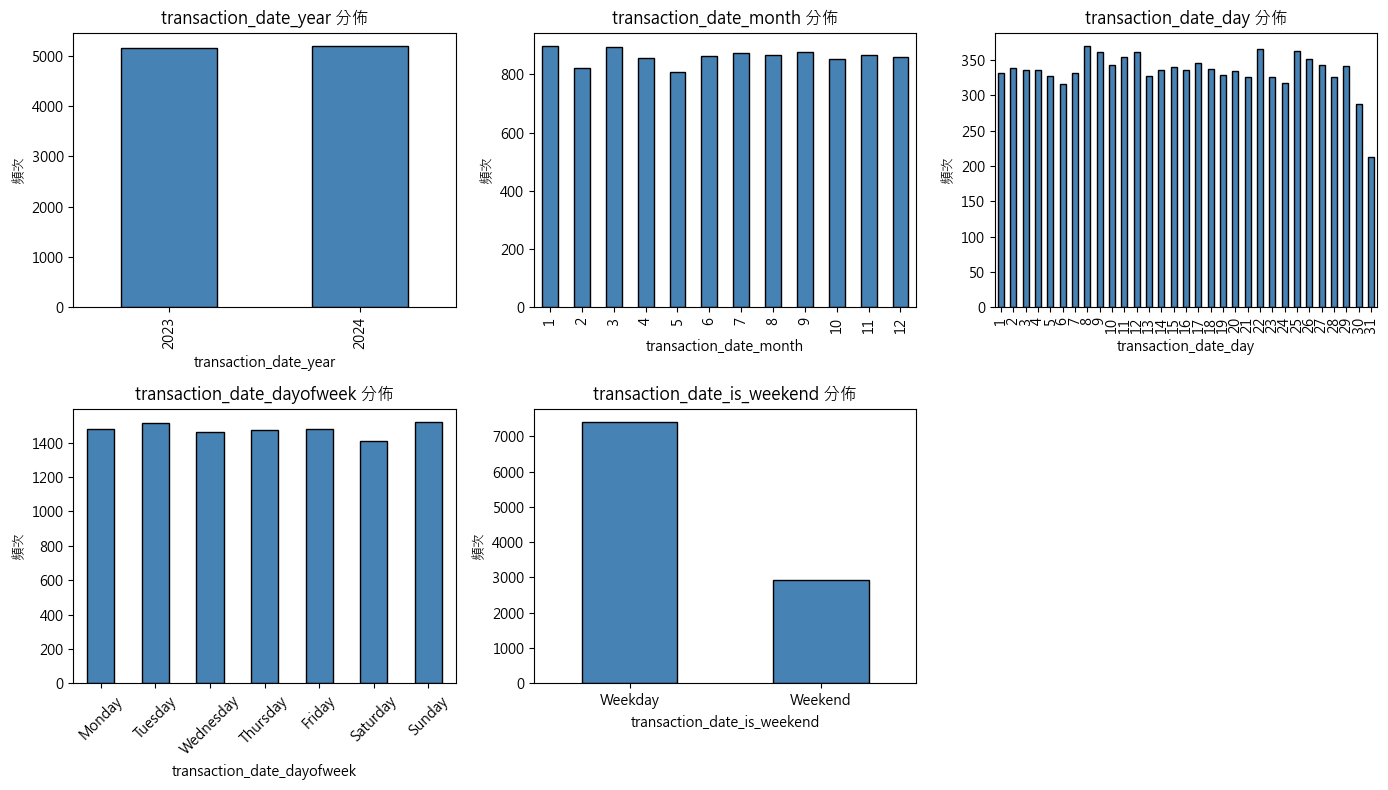

In [11]:
# Interval 統計與時間特徵工程
print("=== Interval 欄位統計與時間特徵提取 ===")
for col in data_types['Interval']:
    if col in df.columns:
        print(f"\n{col}:")
        # 轉換為 datetime 如果還未轉換
        if df[col].dtype == 'object':
            df[col] = pd.to_datetime(df[col], errors='coerce')
        
        # 統計摘要
        print(f"  計數: {df[col].count()}")
        print(f"  開始時間: {df[col].min()}")
        print(f"  結束時間: {df[col].max()}")
        print(f"  時間跨度: {(df[col].max() - df[col].min()).days} 天")
        print(f"  缺失值: {df[col].isna().sum()}")
        
        # 時間特徵工程：提取年、月、日、星期幾、是否週末
        df[f'{col}_year'] = df[col].dt.year
        df[f'{col}_month'] = df[col].dt.month
        df[f'{col}_day'] = df[col].dt.day
        df[f'{col}_dayofweek'] = df[col].dt.dayofweek  # 0=Monday, 6=Sunday
        df[f'{col}_is_weekend'] = df[col].dt.dayofweek.isin([5, 6]).astype(int)  # 1=Weekend, 0=Weekday
        
        print(f"\n  提取的特徵:")
        print(f"    - {col}_year")
        print(f"    - {col}_month")
        print(f"    - {col}_day")
        print(f"    - {col}_dayofweek (0=Monday, 6=Sunday)")
        print(f"    - {col}_is_weekend (1=Weekend, 0=Weekday)")
        
        # 繪製各特徵的分佈
        fig, axes = plt.subplots(2, 3, figsize=(14, 8))
        
        # Year
        df[f'{col}_year'].value_counts().sort_index().plot(kind='bar', ax=axes[0, 0], color='steelblue', edgecolor='black')
        axes[0, 0].set_title(f'{col}_year 分佈')
        axes[0, 0].set_ylabel('頻次')
        
        # Month
        df[f'{col}_month'].value_counts().sort_index().plot(kind='bar', ax=axes[0, 1], color='steelblue', edgecolor='black')
        axes[0, 1].set_title(f'{col}_month 分佈')
        axes[0, 1].set_ylabel('頻次')
        
        # Day
        df[f'{col}_day'].value_counts().sort_index().plot(kind='bar', ax=axes[0, 2], color='steelblue', edgecolor='black')
        axes[0, 2].set_title(f'{col}_day 分佈')
        axes[0, 2].set_ylabel('頻次')
        
        # Day of Week
        day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
        df[f'{col}_dayofweek'].value_counts().sort_index().plot(kind='bar', ax=axes[1, 0], color='steelblue', edgecolor='black')
        axes[1, 0].set_title(f'{col}_dayofweek 分佈')
        axes[1, 0].set_ylabel('頻次')
        axes[1, 0].set_xticklabels(day_names, rotation=45)
        
        # Is Weekend
        df[f'{col}_is_weekend'].value_counts().sort_index().plot(kind='bar', ax=axes[1, 1], color='steelblue', edgecolor='black')
        axes[1, 1].set_title(f'{col}_is_weekend 分佈')
        axes[1, 1].set_xticklabels(['Weekday', 'Weekend'], rotation=0)
        axes[1, 1].set_ylabel('頻次')
        
        # 隱藏最後一個子圖
        axes[1, 2].axis('off')
        
        plt.tight_layout()
        plt.show()

In [ ]:
# 日期時間型欄位處理（已在上面 Interval 統計中完成）
print("=== 日期時間型欄位轉換完成 ===")
print(f"transaction_date 型態: {df['transaction_date'].dtype}")
print(f"時間範圍: {df['transaction_date'].min()} 到 {df['transaction_date'].max()}")
print(f"缺失值: {df['transaction_date'].isna().sum()}")

=== 相關係數分析 ===
employment_type 映射: {'Salaried': np.int64(0), 'Self-Employed': np.int64(1), 'Student': np.int64(2), 'Unemployed': np.int64(3)}
product_category 映射: {'Beauty': np.int64(0), 'Electronics': np.int64(1), 'Fashion': np.int64(2), 'Home': np.int64(3), 'Sports': np.int64(4)}
location 映射: {'Australia': np.int64(0), 'Canada': np.int64(1), 'Germany': np.int64(2), 'India': np.int64(3), 'UK': np.int64(4), 'USA': np.int64(5)}
customer_segment 映射: {'High Risk': np.int64(0), 'Low Risk': np.int64(1), 'Medium Risk': np.int64(2)}
transaction_date (原始 datetime 列) 已移除，使用提取的時間特徵代替

分析的欄位: ['user_id', 'age', 'employment_type', 'monthly_income', 'credit_score', 'purchase_amount', 'product_category', 'bnpl_installments', 'repayment_delay_days', 'missed_payments', 'default_flag', 'app_usage_frequency', 'location', 'debt_to_income_ratio', 'risk_score', 'customer_segment', 'transaction_date_is_weekend']


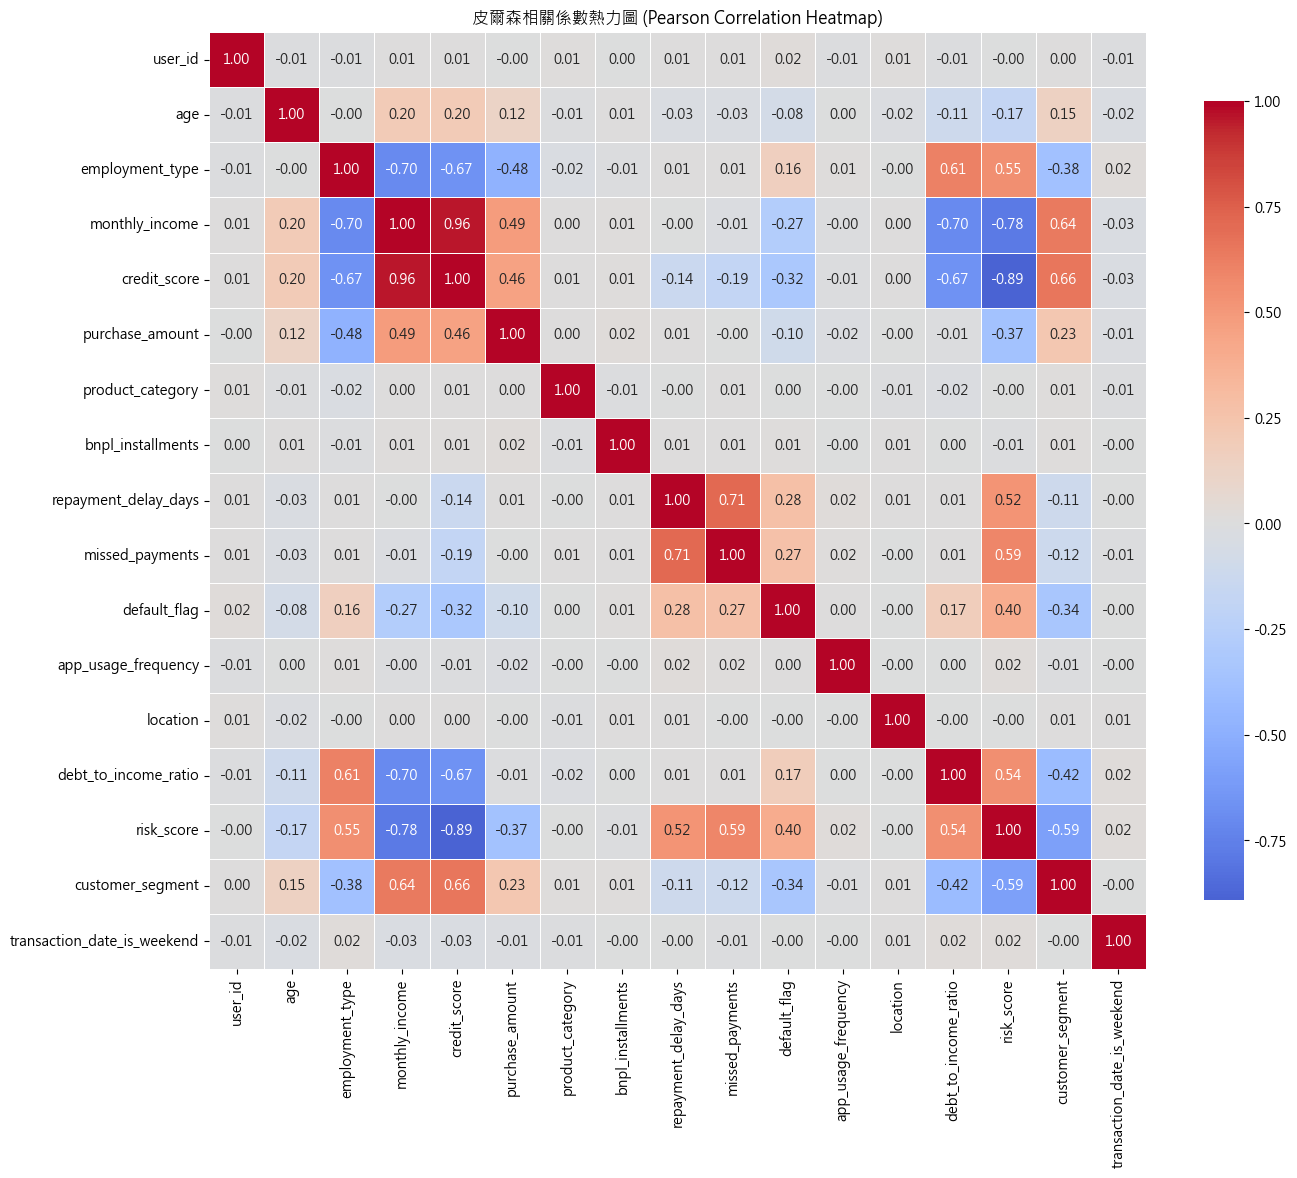

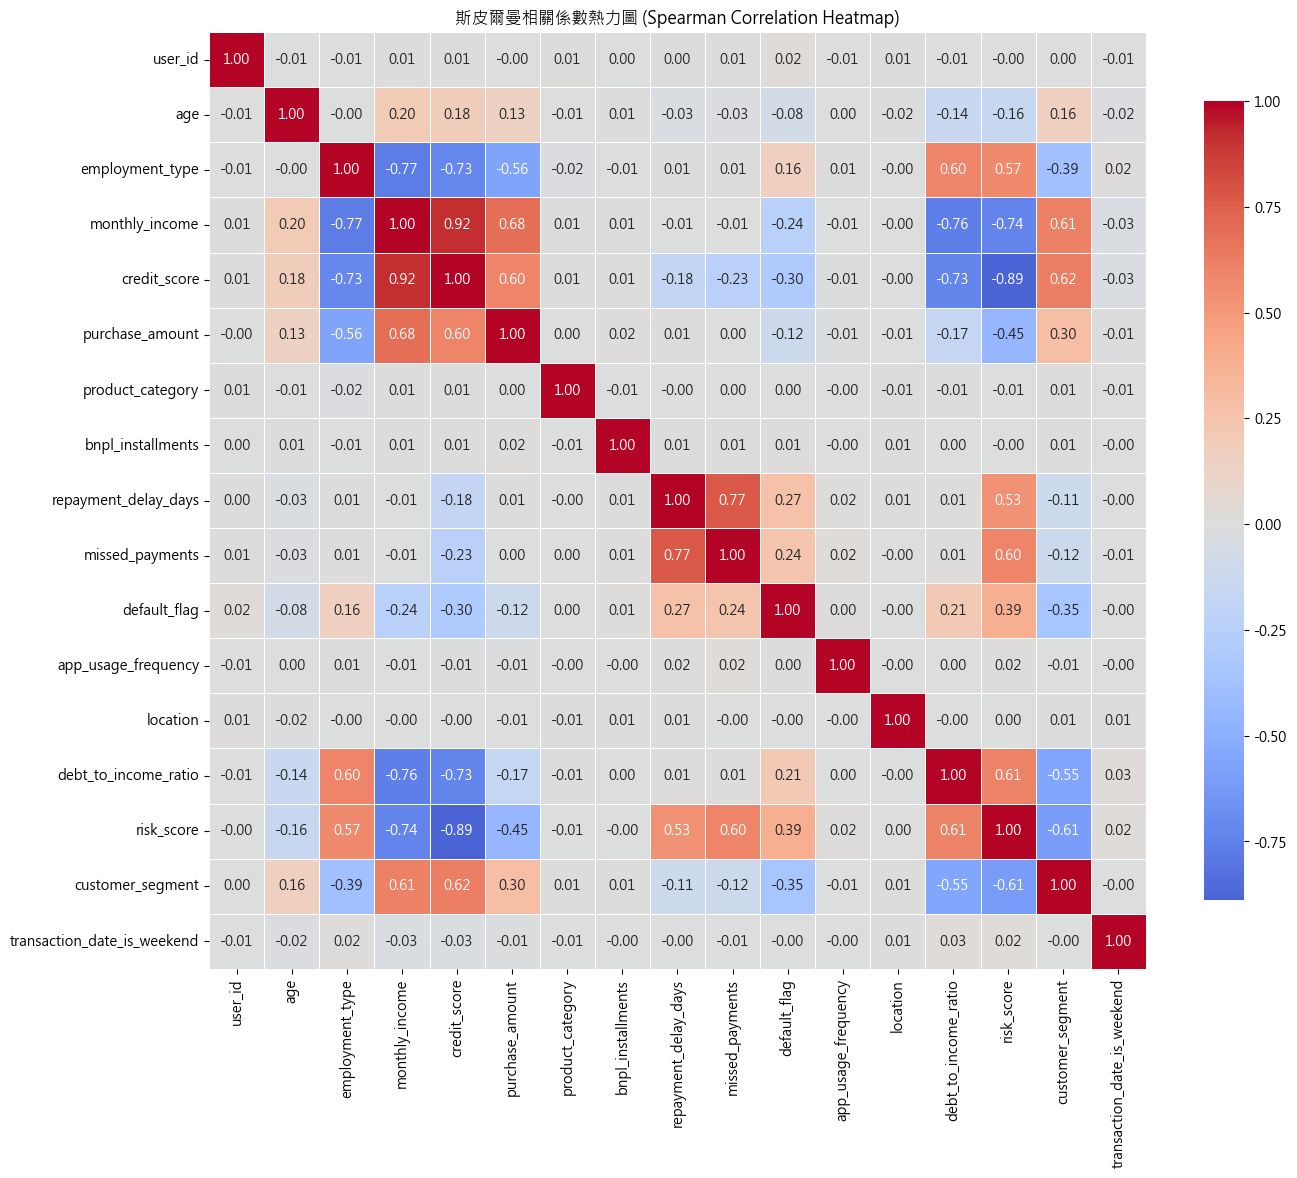


皮爾森相關係數矩陣:


,user_id,age,employment_type,monthly_income,credit_score,purchase_amount,product_category,bnpl_installments,repayment_delay_days,missed_payments,default_flag,app_usage_frequency,location,debt_to_income_ratio,risk_score,customer_segment,transaction_date_is_weekend
user_id,1.000000,-0.008591,-0.009434,0.007664,0.007083,-0.002705,0.013543,0.002276,0.006334,0.009243,0.019243,-0.005798,0.012189,-0.011393,-0.001727,0.003616,-0.006738
age,-0.008591,1.000000,-0.002829,0.200800,0.196636,0.120758,-0.007226,0.006152,-0.027326,-0.031063,-0.075702,0.001992,-0.015528,-0.110355,-0.173636,0.146542,-0.021670
employment_type,-0.009434,-0.002829,1.000000,-0.702143,-0.668797,-0.481002,-0.021373,-0.007799,0.007635,0.009359,0.160794,0.010566,-0.004418,0.611776,0.545019,-0.377818,0.018421
monthly_income,0.007664,0.200800,-0.702143,1.000000,0.960989,0.488607,0.004789,0.011245,-0.004013,-0.012604,-0.274163,-0.004985,0.002973,-0.700067,-0.781487,0.642536,-0.030018
credit_score,0.007083,0.196636,-0.668797,0.960989,1.000000,0.457090,0.006581,0.010336,-0.136305,-0.188617,-0.324238,-0.010793,0.003094,-0.669564,-0.891544,0.657289,-0.028395
purchase_amount,-0.002705,0.120758,-0.481002,0.488607,0.457090,1.000000,0.002735,0.017927,0.007619,-0.004202,-0.097912,-0.015318,-0.002050,-0.008154,-0.369269,0.226508,-0.013178
product_category,0.013543,-0.007226,-0.021373,0.004789,0.006581,0.002735,1.000000,-0.005742,-0.000783,0.005662,0.000220,-0.002734,-0.012037,-0.015917,-0.003807,0.014531,-0.007324
bnpl_installments,0.002276,0.006152,-0.007799,0.011245,0.010336,0.017927,-0.005742,1.000000,0.005590,0.007418,0.012244,-0.002601,0.007857,0.001426,-0.005044,0.012416,-0.000389
repayment_delay_days,0.006334,-0.027326,0.007635,-0.004013,-0.136305,0.007619,-0.000783,0.005590,1.000000,0.713719,0.283209,0.018365,0.007135,0.009272,0.521674,-0.109914,-0.001544
missed_payments,0.009243,-0.031063,0.009359,-0.012604,-0.188617,-0.004202,0.005662,0.007418,0.713719,1.000000,0.272267,0.017108,-0.003804,0.005638,0.590971,-0.118332,-0.006190



斯皮爾曼相關係數矩陣:


,user_id,age,employment_type,monthly_income,credit_score,purchase_amount,product_category,bnpl_installments,repayment_delay_days,missed_payments,default_flag,app_usage_frequency,location,debt_to_income_ratio,risk_score,customer_segment,transaction_date_is_weekend
user_id,1.000000,-0.008680,-0.009435,0.006857,0.006356,-0.002730,0.013481,0.002285,0.004627,0.007599,0.019243,-0.005624,0.012170,-0.008901,-0.002963,0.003249,-0.006738
age,-0.008680,1.000000,-0.002806,0.202487,0.175354,0.129444,-0.007275,0.006057,-0.027591,-0.025147,-0.075622,0.001979,-0.015363,-0.137650,-0.157483,0.162778,-0.021600
employment_type,-0.009435,-0.002806,1.000000,-0.771652,-0.725493,-0.563940,-0.021399,-0.007763,0.007990,0.009422,0.160357,0.010415,-0.004441,0.596579,0.565818,-0.386872,0.018351
monthly_income,0.006857,0.202487,-0.771652,1.000000,0.917798,0.683467,0.006728,0.008456,-0.005765,-0.009993,-0.242133,-0.010355,-0.001214,-0.763407,-0.735334,0.608953,-0.031562
credit_score,0.006356,0.175354,-0.725493,0.917798,1.000000,0.599005,0.011029,0.010397,-0.175262,-0.234733,-0.302947,-0.013410,-0.000867,-0.731247,-0.888907,0.617893,-0.029390
purchase_amount,-0.002730,0.129444,-0.563940,0.683467,0.599005,1.000000,0.003563,0.016228,0.008083,0.001119,-0.115649,-0.012417,-0.005721,-0.171407,-0.453112,0.298876,-0.014936
product_category,0.013481,-0.007275,-0.021399,0.006728,0.011029,0.003563,1.000000,-0.005734,-0.000588,0.003248,0.000383,-0.002718,-0.012000,-0.012678,-0.007114,0.012779,-0.007448
bnpl_installments,0.002285,0.006057,-0.007763,0.008456,0.010397,0.016228,-0.005734,1.000000,0.006689,0.006454,0.012234,-0.002730,0.007757,0.000850,-0.003048,0.012049,-0.000367
repayment_delay_days,0.004627,-0.027591,0.007990,-0.005765,-0.175262,0.008083,-0.000588,0.006689,1.000000,0.774901,0.269058,0.018086,0.007973,0.011994,0.528522,-0.111800,-0.001517
missed_payments,0.007599,-0.025147,0.009422,-0.009993,-0.234733,0.001119,0.003248,0.006454,0.774901,1.000000,0.244009,0.019884,-0.001368,0.012274,0.597218,-0.120595,-0.005074


In [12]:
# 相關係數分析
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

print("=== 相關係數分析 ===")

# 建立一個複製的 dataframe 用於編碼
df_encoded = df.copy()

# 編碼 categorical 變數
categorical_cols = data_types['Categorical']
le_dict = {}

for col in categorical_cols:
    if col in df_encoded.columns:
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
        le_dict[col] = le
        print(f"{col} 映射: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# 移除原始 datetime 欄位，保留提取的時間特徵
interval_cols = data_types['Interval']
for col in interval_cols:
    if col in df_encoded.columns and pd.api.types.is_datetime64_any_dtype(df_encoded[col]):
        # 刪除原始 datetime 列（不用於相關係數計算）
        df_encoded = df_encoded.drop(columns=[col])
        print(f"{col} (原始 datetime 列) 已移除，使用提取的時間特徵代替")

# 選擇所有可用的欄位進行相關係數分析
all_cols = df_encoded.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"\n分析的欄位: {all_cols}")

if all_cols:
    # 計算皮爾森相關係數
    pearson_corr = df_encoded[all_cols].corr(method='pearson')
    
    # 計算斯皮爾曼相關係數
    spearman_corr = df_encoded[all_cols].corr(method='spearman')
    
    # 畫皮爾森相關係數熱力圖
    plt.figure(figsize=(14, 12))
    sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', center=0, 
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, fmt='.2f')
    plt.title('皮爾森相關係數熱力圖 (Pearson Correlation Heatmap)')
    plt.tight_layout()
    plt.show()
    
    # 畫斯皮爾曼相關係數熱力圖
    plt.figure(figsize=(14, 12))
    sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', center=0, 
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, fmt='.2f')
    plt.title('斯皮爾曼相關係數熱力圖 (Spearman Correlation Heatmap)')
    plt.tight_layout()
    plt.show()
    
    print("\n皮爾森相關係數矩陣:")
    display(pearson_corr)
    
    print("\n斯皮爾曼相關係數矩陣:")
    display(spearman_corr)
else:
    print("沒有找到可分析的欄位。")

In [7]:
import numpy as np
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
import warnings
warnings.filterwarnings('ignore')

print("=" * 60)
print("異常值 (Outlier) 檢測分析")
print("=" * 60)

# 定義要檢測異常值的欄位（數值型且有實際意義）
outlier_columns = ['age', 'monthly_income', 'credit_score', 'purchase_amount',
                   'repayment_delay_days', 'missed_payments', 'app_usage_frequency',
                   'debt_to_income_ratio', 'risk_score', 'bnpl_installments']

print(f"\n分析的欄位: {outlier_columns}")

# ============ 1. IQR 方法檢測異常值 ============
print("\n" + "=" * 60)
print("方法 1: 四分位距法 (IQR Method)")
print("=" * 60)

outliers_iqr = {}
outlier_counts_iqr = {}

for col in outlier_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # 找出異常值
    outlier_mask = (df[col] < lower_bound) | (df[col] > upper_bound)
    outliers_iqr[col] = outlier_mask
    outlier_counts_iqr[col] = outlier_mask.sum()
    
    if outlier_counts_iqr[col] > 0:
        pct = (outlier_counts_iqr[col] / len(df)) * 100
        print(f"\n{col}:")
        print(f"  範圍: [{lower_bound:.2f}, {upper_bound:.2f}]")
        print(f"  異常值數量: {outlier_counts_iqr[col]} ({pct:.2f}%)")
        print(f"  異常值範圍: [{df.loc[outlier_mask, col].min():.2f}, {df.loc[outlier_mask, col].max():.2f}]")

# ============ 2. Z-score 方法 ============
print("\n" + "=" * 60)
print("方法 2: Z-score 方法 (閾值: |z| > 3)")
print("=" * 60)

outliers_zscore = {}
outlier_counts_zscore = {}

for col in outlier_columns:
    z_scores = np.abs(stats.zscore(df[col]))
    outlier_mask = z_scores > 3
    outliers_zscore[col] = outlier_mask
    outlier_counts_zscore[col] = outlier_mask.sum()
    
    if outlier_counts_zscore[col] > 0:
        pct = (outlier_counts_zscore[col] / len(df)) * 100
        print(f"\n{col}:")
        print(f"  異常值數量: {outlier_counts_zscore[col]} ({pct:.2f}%)")
        print(f"  最大 Z-score: {z_scores.max():.2f}")

# ============ 3. 隔離森林 (Isolation Forest) ============
print("\n" + "=" * 60)
print("方法 3: 隔離森林 (Isolation Forest)")
print("=" * 60)

# 準備數據
X = df[outlier_columns].copy()

# 應用隔離森林
iso_forest = IsolationForest(contamination=0.05, random_state=42)
outlier_predictions = iso_forest.fit_predict(X)
outlier_mask_if = outlier_predictions == -1

outlier_count_if = outlier_mask_if.sum()
pct_if = (outlier_count_if / len(df)) * 100

print(f"\n異常值數量: {outlier_count_if} ({pct_if:.2f}%)")
print(f"正常值數量: {(~outlier_mask_if).sum()} ({100 - pct_if:.2f}%)")

# ============ 4. 局部離群因子 (LOF) ============
print("\n" + "=" * 60)
print("方法 4: 局部離群因子 (Local Outlier Factor)")
print("=" * 60)

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
outlier_predictions_lof = lof.fit_predict(X)
outlier_mask_lof = outlier_predictions_lof == -1

outlier_count_lof = outlier_mask_lof.sum()
pct_lof = (outlier_count_lof / len(df)) * 100

print(f"\n異常值數量: {outlier_count_lof} ({pct_lof:.2f}%)")
print(f"正常值數量: {(~outlier_mask_lof).sum()} ({100 - pct_lof:.2f}%)")

# ============ 5. 綜合異常值檢測 ============
print("\n" + "=" * 60)
print("異常值檢測方法比較總結")
print("=" * 60)

summary_data = {
    '方法': ['IQR (平均)', 'Z-score', '隔離森林', 'LOF'],
    '異常值數量': [
        sum(outlier_counts_iqr.values()),
        sum(outlier_counts_zscore.values()),
        outlier_count_if,
        outlier_count_lof
    ],
    '異常值百分比': [
        f"{(sum(outlier_counts_iqr.values()) / len(df)) * 100:.2f}%",
        f"{(sum(outlier_counts_zscore.values()) / len(df)) * 100:.2f}%",
        f"{pct_if:.2f}%",
        f"{pct_lof:.2f}%"
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n")
display(summary_df)

異常值 (Outlier) 檢測分析

分析的欄位: ['age', 'monthly_income', 'credit_score', 'purchase_amount', 'repayment_delay_days', 'missed_payments', 'app_usage_frequency', 'debt_to_income_ratio', 'risk_score', 'bnpl_installments']

方法 1: 四分位距法 (IQR Method)

monthly_income:
  範圍: [-52397.85, 119881.80]
  異常值數量: 25 (0.24%)
  異常值範圍: [119935.82, 145767.12]

repayment_delay_days:
  範圍: [-16.00, 32.00]
  異常值數量: 1 (0.01%)
  異常值範圍: [33.00, 33.00]

missed_payments:
  範圍: [-3.00, 5.00]
  異常值數量: 8 (0.08%)
  異常值範圍: [6.00, 7.00]

debt_to_income_ratio:
  範圍: [-0.20, 0.55]
  異常值數量: 57 (0.55%)
  異常值範圍: [0.55, 0.72]

risk_score:
  範圍: [7.80, 396.60]
  異常值數量: 31 (0.30%)
  異常值範圍: [0.00, 398.00]

方法 2: Z-score 方法 (閾值: |z| > 3)

monthly_income:
  異常值數量: 38 (0.37%)
  最大 Z-score: 4.09

repayment_delay_days:
  異常值數量: 7 (0.07%)
  最大 Z-score: 3.58

missed_payments:
  異常值數量: 39 (0.38%)
  最大 Z-score: 6.00

debt_to_income_ratio:
  異常值數量: 51 (0.49%)
  最大 Z-score: 4.34

方法 3: 隔離森林 (Isolation Forest)

異常值數量: 518 (5.01%)
正常值數量: 9827 (9

,方法,異常值數量,異常值百分比
0,IQR (平均),122,1.18%
1,Z-score,135,1.30%
2,隔離森林,518,5.01%
3,LOF,518,5.01%


## 異常值 (Outlier) 探索與檢測

異常值是指明顯偏離其他數據點的值。有多種方法可以檢測異常值：
1. **四分位距法 (IQR)**：基於四分位數，適合用於有明確分布的數據
2. **Z-score 法**：衡量數據點距離平均值的標準差距離
3. **隔離森林 (Isolation Forest)**：機器學習方法，適合高維數據
4. **Local Outlier Factor (LOF)**：基於局部密度的異常值檢測

在信貸風險數據中，異常值可能表示：
- 異常的收入或消費行為
- 不尋常的延遲或違約情況
- 數據輸入錯誤


異常值可視化 - Box Plot


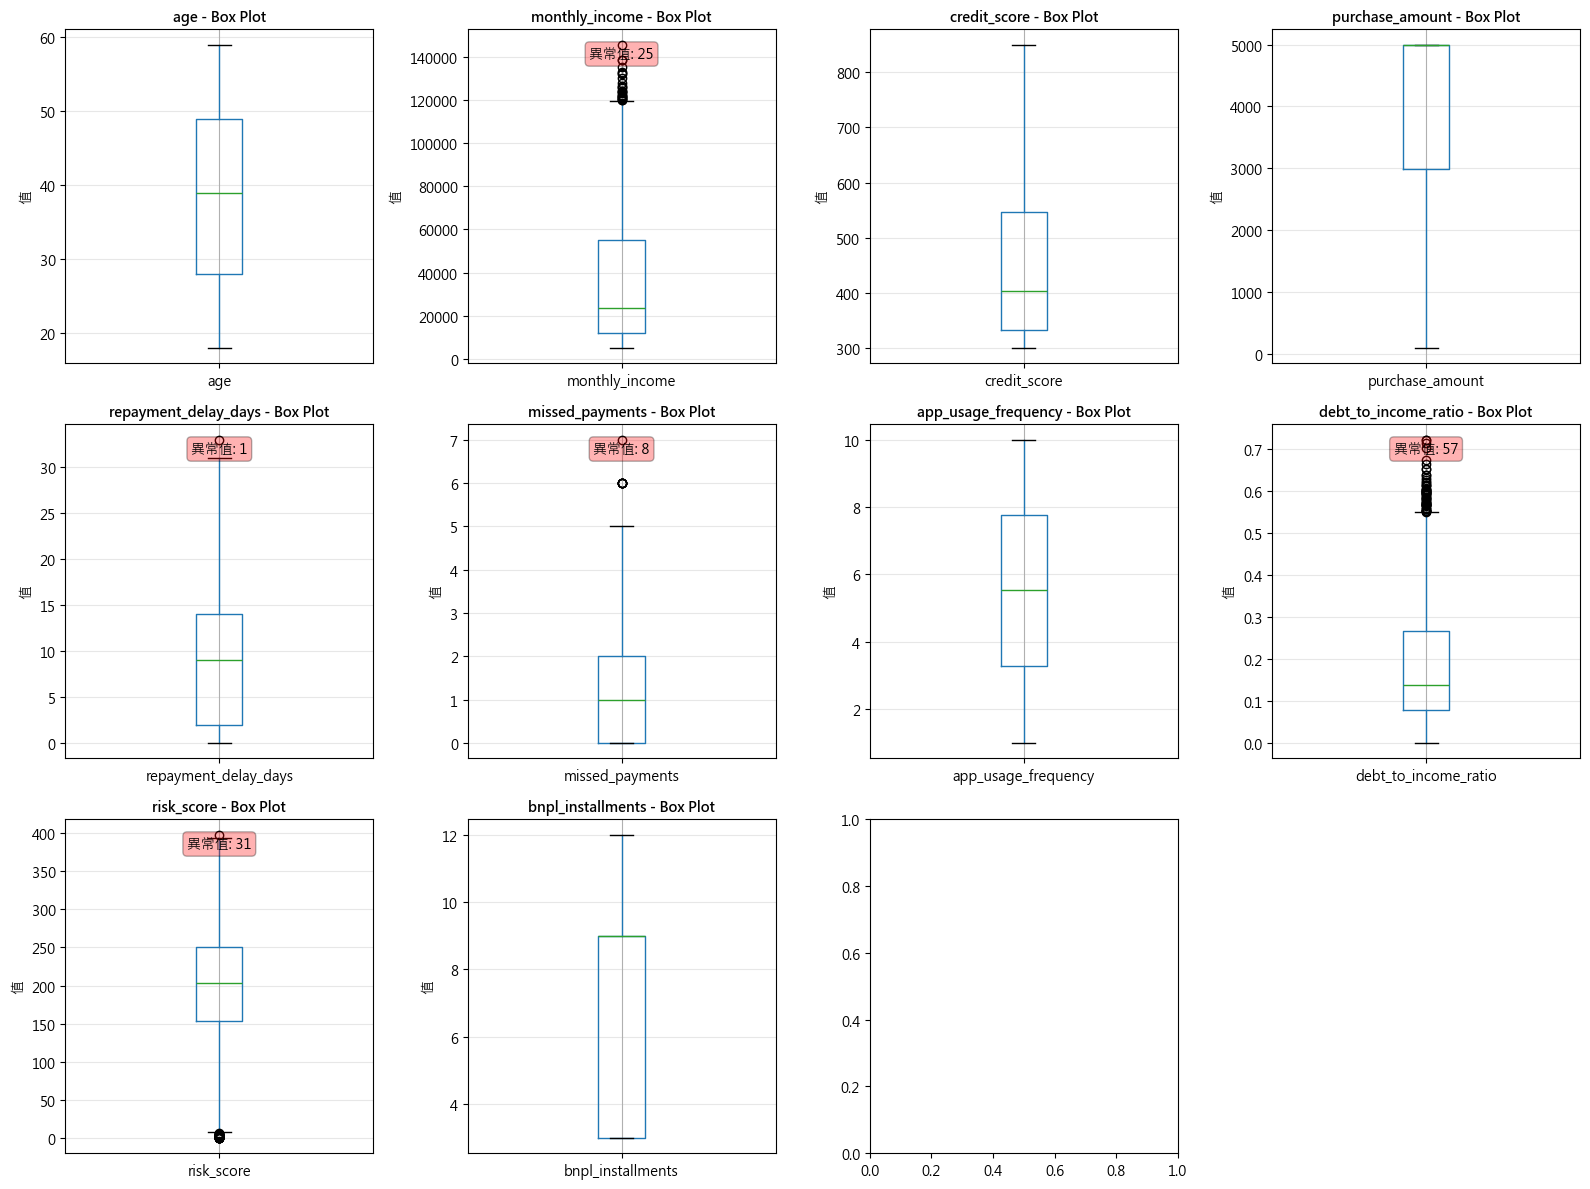


✅ Box Plot 顯示了各欄位中的異常值


In [8]:
print("=" * 60)
print("異常值可視化 - Box Plot")
print("=" * 60)

# 繪製 Box Plot
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for idx, col in enumerate(outlier_columns):
    ax = axes[idx]
    df.boxplot(column=col, ax=ax)
    ax.set_title(f"{col} - Box Plot", fontsize=10, fontweight='bold')
    ax.set_ylabel('值')
    ax.grid(axis='y', alpha=0.3)
    
    # 標記異常值數量
    outlier_count = outlier_counts_iqr.get(col, 0)
    if outlier_count > 0:
        ax.text(0.5, 0.95, f"異常值: {outlier_count}", 
                transform=ax.transAxes, ha='center', va='top',
                bbox=dict(boxstyle='round', facecolor='red', alpha=0.3))

# 隱藏最後一個子圖
axes[-1].axis('off')

plt.tight_layout()
plt.show()

print("\n✅ Box Plot 顯示了各欄位中的異常值")

## 異常值可視化

使用 Box Plot 可以直觀地看出異常值的分佈。Box plot 顯示：
- 中間的線：中位數 (median)
- 方框：四分位距 (IQR)，包含 50% 的數據
- 鬚線：正常範圍的邊界
- 圓點：超出鬚線的異常值
